# TensorFlow lab: MNIST classification with `tf.data`

In this exercise you'll build an image classification pipeline end to end: turn a folder of PNG files into a `tf.data.Dataset`, train a small CNN with `tf.keras`, and run inference on a single raw image.

**How to work through this notebook**
- Every task cell is marked `# TODO`. Replace the placeholder with your own code.
- Several tasks end with an `assert` — it will raise with an explanatory message if the task isn't done yet. Don't remove or edit the asserts; they exist to catch mistakes early, before a confusing error shows up three cells later.
- Run cells top to bottom. Later tasks depend on variables defined in earlier ones (`mnist_df`, `make_dataset`, `model`, ...).
- This notebook is self-contained: it only assumes a `data/mnist/<split>/<class>/<file>.png` folder layout (adjust `MNIST_DIR` below if yours differs).

## 1. Imports

In [3]:
%pip install tensorflow opencv-python matplotlib numpy pandas

In [4]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

## 2. Paths

`MNIST_DIR` should point at a folder containing `train/<class>/*.png` and `test/<class>/*.png`. `CHECKPOINT_PATH` is where the training callback (task 8) will save the best model weights.

In [5]:
MNIST_DIR = Path('../mnist')
CHECKPOINT_PATH = Path('mnist_best.weights.h5')

### Download MNIST automatically

On the first run, the next cell downloads MNIST through Keras and exports it to the folder layout used in this lab. The `.complete` marker prevents the 70,000 PNG files from being written again on later runs. An internet connection is needed only for the initial download.

In [6]:
dataset_marker = MNIST_DIR / '.complete'

if not dataset_marker.exists():
    print('Downloading MNIST and creating PNG folders...')
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    for split, images, labels in (
        ('train', x_train, y_train),
        ('test', x_test, y_test),
    ):
        for digit in range(10):
            (MNIST_DIR / split / str(digit)).mkdir(parents=True, exist_ok=True)

        for index, (image, label) in enumerate(zip(images, labels)):
            output_path = MNIST_DIR / split / str(int(label)) / f'{index}.png'
            if not cv2.imwrite(str(output_path), image):
                raise OSError(f'Could not write {output_path}')

    dataset_marker.touch()
    print(f'MNIST saved to: {MNIST_DIR.resolve()}')
else:
    print(f'MNIST is already available at: {MNIST_DIR.resolve()}')

assert dataset_marker.exists(), 'MNIST download/export did not finish successfully.'

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST saved to: /mnist


## 3. Task: build a manifest DataFrame

Walk `MNIST_DIR` and build a `pandas.DataFrame` describing every image, with one row per file and three columns:

- `path` — the image's path (e.g. relative to `MNIST_DIR`), as a string
- `class` — the digit label (`0`-`9`), as an int
- `split` — `'train'` or `'test'`

The label and split can both be read straight off the folder structure: `<split>/<class>/<file>.png`.

Expected shape, e.g.:

| path | class | split |
|---|---|---|
| train/0/1.png | 0 | train |
| train/7/842.png | 7 | train |
| test/3/91.png | 3 | test |

Saving it to a CSV (e.g. with `mnist_df.to_csv(...)`) is optional but is handy if you want to reload the manifest later without re-scanning the filesystem.

In [7]:
records = []
for split in ('train', 'test'):
    for image_path in sorted((MNIST_DIR / split).glob('*/*.png')):
        records.append({'path': str(image_path.relative_to(MNIST_DIR)),
                        'class': int(image_path.parent.name),
                        'split': split})
mnist_df = pd.DataFrame(records, columns=['path', 'class', 'split'])
print(f'Found {len(mnist_df):,} images')
display(mnist_df.head())

assert mnist_df is not None, 'Task 3 is not done yet: build mnist_df before continuing.'

Found 70,000 images


,path,class,split
0,train/0/1.png,0,train
1,train/0/1000.png,0,train
2,train/0/10005.png,0,train
3,train/0/10010.png,0,train
4,train/0/10022.png,0,train


## 4. Task: visualize random samples

Sample a handful of rows from `mnist_df` and plot them in a grid with their labels as titles, as a sanity check on the manifest.

Hints: `mnist_df.sample(...)`, `cv2.imread(path, cv2.IMREAD_GRAYSCALE)` to load an image, `plt.subplots(...)` + `ax.imshow(...)` to build the grid.

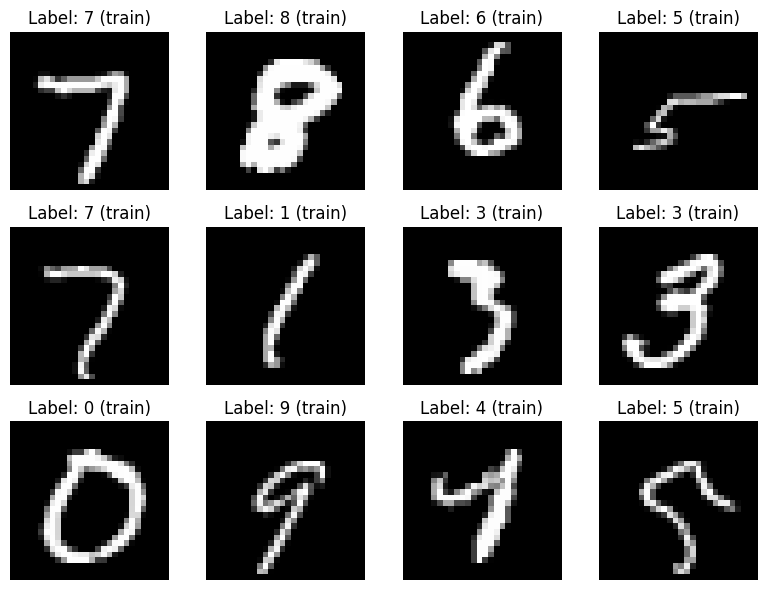

In [8]:
n_samples = min(12, len(mnist_df))
samples = mnist_df.sample(n=n_samples, random_state=42)
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax in axes.flat:
    ax.axis('off')
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    image = cv2.imread(str(MNIST_DIR / row['path']), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not read {MNIST_DIR / row['path']}")
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {row['class']} ({row['split']})")
plt.tight_layout()
plt.show()

## 5. Task: build a `tf.data.Dataset`

[`tf.data.Dataset`](https://www.tensorflow.org/guide/data) ([API reference](https://www.tensorflow.org/api_docs/python/tf/data/Dataset)) represents a pipeline of elements plus a chain of transformations (map, filter, batch, ...) applied to them lazily, one element at a time, as the model asks for data. Building the pipeline out of native TensorFlow ops (instead of e.g. loading everything into a big NumPy array upfront) means it can stream from disk, run in parallel, and overlap loading with training.

The pipeline you'll build goes:

1. **`path_ds` / `label_ds`** — two `tf.data.Dataset`s built straight from `mnist_df`'s columns with `tf.data.Dataset.from_tensor_slices`: one of file path strings, one of integer labels.
2. **`zip`** — `tf.data.Dataset.zip((path_ds, label_ds))` pairs them up, so each element becomes a `(path, label)` tuple.
3. **`shuffle`** *(optional)* — `.shuffle(buffer_size)` randomizes the order elements come out in, so training doesn't see whole runs of the same class back to back just because of how the files happen to be sorted on disk. Skip it for validation/test data, where order doesn't matter.
4. **load file** — `tf.io.read_file(path)` reads the PNG's raw bytes off disk.
5. **parse image** — `tf.io.decode_png(bytes, channels=1)` decodes those bytes into an actual image tensor.
6. **normalize** — rescale pixel values from the `[0, 255]` integer range to `[0, 1]` floats, e.g. with `tf.image.convert_image_dtype(image, tf.float32)`. Models train more reliably on small float inputs than on raw byte values.
7. **`batch`** *(optional)* — `.batch(batch_size)` groups consecutive elements into mini-batches. Leaving it `None` yields one example at a time, which is what we want below for inspection and visualization.
8. **`prefetch`** — `.prefetch(tf.data.AUTOTUNE)` lets TensorFlow prepare the next element(s) on CPU while the current one is still being consumed, overlapping I/O with computation instead of doing them one after another.

Fill in `make_dataset` below, then use it to build an unbatched dataset for each split.

In [9]:
def make_dataset(df, shuffle=False, batch_size=None):
    paths = [str(MNIST_DIR / path) for path in df['path']]
    labels = df['class'].to_numpy(dtype=np.int64)
    path_ds = tf.data.Dataset.from_tensor_slices(paths)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    dataset = tf.data.Dataset.zip((path_ds, label_ds))
    if shuffle and len(df) > 0:
        dataset = dataset.shuffle(len(df), seed=42, reshuffle_each_iteration=True)

    def load_image(path, label):
        image = tf.io.decode_png(tf.io.read_file(path), channels=1)
        image = tf.image.convert_image_dtype(image, tf.float32)
        image = tf.ensure_shape(image, (28, 28, 1))
        return image, label

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if batch_size is not None:
        dataset = dataset.batch(batch_size)
    return dataset.prefetch(tf.data.AUTOTUNE)

In [10]:
train_dataset_no_batch = make_dataset(mnist_df[mnist_df.split == 'train'], shuffle=True, batch_size=None)
test_dataset_no_batch = make_dataset(mnist_df[mnist_df.split == 'test'], shuffle=False, batch_size=None)

assert train_dataset_no_batch is not None, 'Task 5 is not done yet: implement make_dataset before continuing.'
assert test_dataset_no_batch is not None, 'Task 5 is not done yet: implement make_dataset before continuing.'

print(train_dataset_no_batch)

<_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


## 6. Task: visualize images from the dataset

We deliberately built `train_dataset_no_batch` *unbatched* — every element is a single `(image, label)` pair rather than a batch of them, which is exactly what you want when you're plotting one image per grid cell. Batching now would just add an extra leading dimension you'd have to index away before calling `imshow`.

Pull a handful of elements out with `train_dataset_no_batch.take(n)` and plot them with `matplotlib`, the same way you did in task 4 — except this time the images are coming through the `tf.data` pipeline you just built, not straight from `cv2.imread`. This is a good way to confirm loading, decoding, and normalization are all correct.

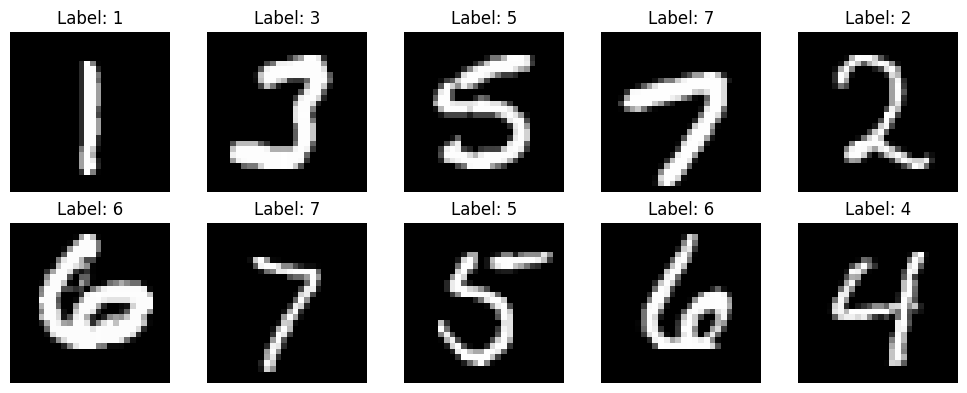

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax in axes.flat:
    ax.axis('off')
for ax, (image, label) in zip(axes.flat, train_dataset_no_batch.take(10)):
    ax.imshow(tf.squeeze(image).numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Label: {int(label.numpy())}')
plt.tight_layout()
plt.show()

## 7. Task: define the model

Build a [`tf.keras.Sequential`](https://www.tensorflow.org/guide/keras/sequential_model) model for 10-class digit classification.

`Sequential` is the simplest way to build a Keras model: a plain stack of layers, each with exactly one input and one output, feeding directly into the next. You build it by passing a list of layers in order — it's the right tool whenever your model is a single linear chain (as ours is here); if you ever need multiple inputs/outputs, shared layers, or branches/skip connections, that's what the Functional API is for instead.

A reasonable architecture for MNIST: an `Input` layer for the `(28, 28, 1)` images, one or two `Conv2D` + `MaxPooling2D` blocks to extract features, a `Flatten`, then a `Dense` head ending in a 10-unit `softmax` output layer.

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax'),
])

assert model is not None, 'Task 7 is not done yet: define your Sequential model before continuing.'

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Task: compile the model

Compile with the standard pattern:

- `optimizer='adam'`
- a loss suited to integer (not one-hot) class labels
- `metrics=['accuracy']`

Then create a [`tf.keras.callbacks.ModelCheckpoint`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint) that watches validation accuracy and saves only the best epoch's weights to `CHECKPOINT_PATH`.

In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(CHECKPOINT_PATH), monitor='val_accuracy', mode='max',
    save_best_only=True, save_weights_only=True, verbose=1
)

## 9. Task: train the model

Build batched train/val datasets with `make_dataset` (this time passing `batch_size=BATCH_SIZE`), then train with [`model.fit`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit), passing `validation_data=val_ds`, `epochs=EPOCHS`, and `callbacks=[checkpoint_callback]`.

In [14]:
BATCH_SIZE = 32
EPOCHS = 5

train_ds = make_dataset(mnist_df[mnist_df.split == 'train'],
                        shuffle=True, batch_size=BATCH_SIZE)
val_ds = make_dataset(mnist_df[mnist_df.split == 'test'],
                      shuffle=False, batch_size=BATCH_SIZE)

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                    callbacks=[checkpoint_callback])

Epoch 1/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8945 - loss: 0.3484
Epoch 1: val_accuracy improved from None to 0.98570, saving model to mnist_best.weights.h5

Epoch 1: finished saving model to mnist_best.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.9513 - loss: 0.1628 - val_accuracy: 0.9857 - val_loss: 0.0442
Epoch 2/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9806 - loss: 0.0594
Epoch 2: val_accuracy improved from 0.98570 to 0.98840, saving model to mnist_best.weights.h5

Epoch 2: finished saving model to mnist_best.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9822 - loss: 0.0568 - val_accuracy: 0.9884 - val_loss: 0.0380
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9872 - loss: 0.0416
Epoch 3: val_accuracy improved from 0.98840 to 0.99020, saving model to mnist_best.weights.h5

Epoch 3: finished saving model to mnist_best.weights.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step

## 10. Task: visualize training metrics

`history.history` is a dict of per-epoch metric lists (`'loss'`, `'val_loss'`, `'accuracy'`, `'val_accuracy'`). Turn it into a `pandas.DataFrame` and plot loss and accuracy (train vs. validation) to check for over/underfitting.

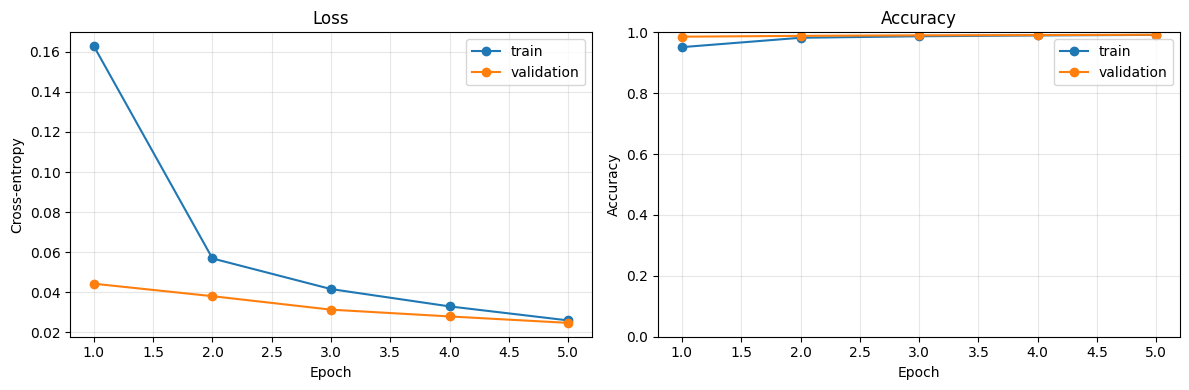

In [15]:
metrics_df = pd.DataFrame(history.history)
epochs = np.arange(1, len(metrics_df) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, metrics_df['loss'], marker='o', label='train')
axes[0].plot(epochs, metrics_df['val_loss'], marker='o', label='validation')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Cross-entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, metrics_df['accuracy'], marker='o', label='train')
axes[1].plot(epochs, metrics_df['val_accuracy'], marker='o', label='validation')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1))
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Task: inference on a custom sample

Run the trained model on a single raw image file, end to end:

1. **Load** the best checkpoint (`model.load_weights(CHECKPOINT_PATH)`), then read one PNG file straight from `MNIST_DIR` with `cv2.imread`.
2. **Normalize** it the same way the training pipeline did (scale to `[0, 1]` floats).
3. **To tensor** — reshape it to a batch of one, `(1, 28, 28, 1)`, matching what the model expects.
4. **Predict** with `model.predict(...)`.
5. **Decode** the prediction: `np.argmax` over the 10 output probabilities gives the predicted digit.

Display the image with the true label (from the filename/folder) and the predicted label side by side.

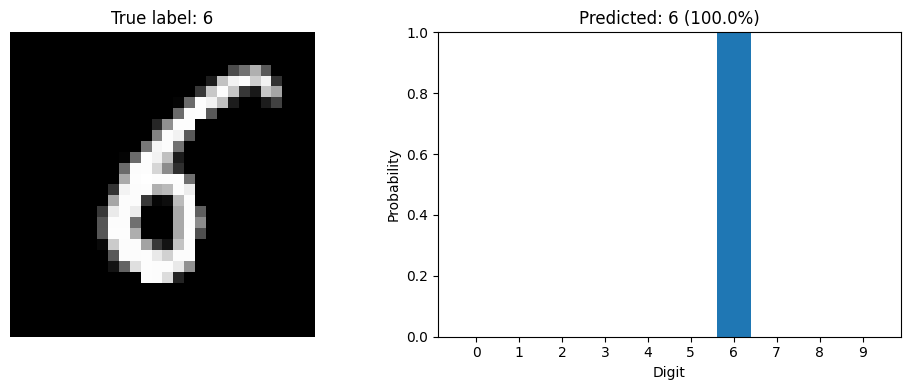

In [16]:
model.load_weights(str(CHECKPOINT_PATH))

sample = mnist_df[mnist_df.split == 'test'].sample(n=1, random_state=42).iloc[0]
sample_path = MNIST_DIR / sample['path']
raw_image = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
if raw_image is None:
    raise ValueError(f'Could not read {sample_path}')
if raw_image.shape != (28, 28):
    raw_image = cv2.resize(raw_image, (28, 28), interpolation=cv2.INTER_AREA)

normalized_image = raw_image.astype(np.float32) / 255.0
input_tensor = normalized_image[np.newaxis, ..., np.newaxis]
probabilities = model.predict(input_tensor, verbose=0)[0]
predicted_label = int(np.argmax(probabilities))
true_label = int(sample['class'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(raw_image, cmap='gray')
axes[0].set_title(f'True label: {true_label}')
axes[0].axis('off')
axes[1].bar(np.arange(10), probabilities)
axes[1].set(xticks=np.arange(10), ylim=(0, 1), xlabel='Digit',
            ylabel='Probability',
            title=f'Predicted: {predicted_label} ({probabilities[predicted_label]:.1%})')
plt.tight_layout()
plt.show()